# 🔥 Forest Fires in Brazil - Análise Exploratória de Dados

Este notebook apresenta a análise exploratória do dataset *Forest Fires in Brazil*, que contém dados de focos de incêndio em todo o Brasil entre 1998 e 2017.


In [13]:
#Carregamento de Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid") #fundo branco dos plots


## Coleta dos dados

- **Período e Fonte**:
  - O dataset contém dados sobre os incêndios florestais no Brasil no período de 1998 a 2017.
  - Fonte: Sistema Nacional de Informações Florestais (SNIF) - [dados.gov.br](http://dados.gov.br/dataset/sistema-nacional-de-informacoes-florestais-snif)

- **Colunas principais**:
  - `year`: Ano do registro
  - `state`: Estado do Brasil
  - `month`: Mês do ano
  - `number`: Número de focos de incêndio

- **Volume de dados**:
  - O dataset possui mais de 6.000 registros abrangendo todos os estados do Brasil.

---

## Pré-processamento

In [14]:
def carregar_dados(caminho: str) -> pd.DataFrame:
    df = pd.read_csv(caminho, encoding="utf-8").copy()
    return df

def salvar_copia(df: pd.DataFrame):
    df.to_csv('./data/amazonfire_edit.csv', index=False, encoding='utf-8')

def remover_nulos(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["number"].notnull()]

def remover_outliers(df: pd.DataFrame) -> pd.DataFrame:
    q1 = df["number"].quantile(0.25)
    q3 = df["number"].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Cria filtro booleano
    filtro = (df["number"] >= lim_inf) & (df["number"] <= lim_sup)

    # Filtra dados e converte para int
    df_filtrado = df[filtro].copy()
    df_filtrado["number"] = df_filtrado["number"].astype(int)

    # Identifica outliers
    outliers = df[~filtro]
    print(f"Número de outliers removidos: {len(outliers)}")
    print("Outliers removidos:")
    print(outliers)

    return df_filtrado

def mapear_meses(df: pd.DataFrame) -> pd.DataFrame:

    meses_info = {
        'janeiro':  {'num': 1,  'alias': 'jan'},
        'fevereiro':{'num': 2,  'alias': 'fev'},
        'março':    {'num': 3,  'alias': 'mar'},
        'abril':    {'num': 4,  'alias': 'abr'},
        'maio':     {'num': 5,  'alias': 'mai'},
        'junho':    {'num': 6,  'alias': 'jun'},
        'julho':    {'num': 7,  'alias': 'jul'},
        'agosto':   {'num': 8,  'alias': 'ago'},
        'setembro': {'num': 9,  'alias': 'set'},
        'outubro':  {'num': 10, 'alias': 'out'},
        'novembro': {'num': 11, 'alias': 'nov'},
        'dezembro': {'num': 12, 'alias': 'dez'}
    }

    # Padroniza o texto
    meses_clean = df['month'].astype(str).str.strip().str.lower()
    
    # Cria colunas vazias
    df['month_num'] = meses_clean.map(lambda x: meses_info.get(x, {}).get('num'))
    df['month_alias'] = meses_clean.map(lambda x: meses_info.get(x, {}).get('alias'))

    print("Meses não mapeados:", df['month_num'].isna().sum())
    print("Meses não mapeados únicos:", df.loc[df['month_num'].isna(), 'month'].unique())
    
    return df

def criar_coluna_data(df: pd.DataFrame) -> pd.DataFrame:
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month_num'], day=1))
    return df

def adicionar_regiao(df: pd.DataFrame) -> pd.DataFrame:
    #print("Estados únicos no DataFrame:")
    #print(df['state'].unique())

    # Dicionário com acentos nos nomes dos estados
    regioes = {
        "Norte": ["Acre", "Amapa", "Amazonas", "Pará", "Rondonia", "Roraima", "Tocantins"],
        "Nordeste": ["Alagoas", "Bahia", "Ceara", "Maranhao", "Paraiba", "Pernambuco", "Piauí", "Rio Grande do Norte", "Sergipe"],
        "Centro-Oeste": ["Goias", "Mato Grosso", "Mato Grosso do Sul", "Distrito Federal"],
        "Sudeste": ["Espirito Santo", "Minas Gerais", "Rio de Janeiro", "Sao Paulo"],
        "Sul": ["Paraná", "Rio Grande do Sul", "Santa Catarina"]
    }

    # Cria dicionário plano {estado: regiao}
    estado_para_regiao = {estado: regiao for regiao, estados in regioes.items() for estado in estados}

    # Faz o mapeamento direto
    df['regiao'] = df['state'].map(estado_para_regiao)

    # Diagnóstico
    n_nan = df['regiao'].isna().sum()
    print(f"\nNúmero de estados sem região atribuída: {n_nan}")
    if n_nan > 0:
        estados_nao_mapeados = df.loc[df['regiao'].isna(), 'state'].unique()
        print("Estados não mapeados:", estados_nao_mapeados)

    return df

def preprocessar_geral(caminho_csv: str) -> pd.DataFrame:
    df = carregar_dados(caminho_csv)
    df = remover_nulos(df)
    #df = remover_outliers(df)
    df = mapear_meses(df)
    df = criar_coluna_data(df)
    df = adicionar_regiao(df)
    return df



## EDA

In [15]:
#eda.py
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df: pd.DataFrame, pasta_plots="./output/plots"):
    """
    Realiza Análise Exploratória de Dados (EDA) sobre dados de incêndios florestais no Brasil.
    Gera gráficos e os salva na pasta especificada.

    Parâmetros:
        df (pd.DataFrame): DataFrame com colunas ['year', 'month_num', 'state', 'number', 'regiao']
        pasta_plots (str): Caminho para salvar os gráficos gerados
    """

    # Checagem
    colunas_esperadas = {'year', 'month_num', 'state', 'number', 'regiao'}
    if not colunas_esperadas.issubset(df.columns):
        raise ValueError(f"O DataFrame deve conter as colunas: {colunas_esperadas}")

    # ---------- 4.1 Total de incêndios por ano ----------
    df_total_ano = df.groupby("year", as_index=False)["number"].sum()
    df_total_ano["year"] = df_total_ano["year"].astype(int)
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_total_ano, x='year', y='number', marker='o')
    plt.xticks(ticks=df_total_ano["year"])
    plt.title("Número Total de Incêndios por Ano")
    plt.xlabel("Ano")
    plt.ylabel("Número de Incêndios")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Total de incêndios por mes
    df_total_mes = df.groupby("month_num", as_index=False)["number"].sum()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_total_mes, x='month_num', y='number', marker='o', color='blue')
    plt.title("Total de Incêndios por Mês (1998–2017)")
    plt.xlabel("Mês")
    plt.ylabel("Número total de incêndios")
    plt.xticks(ticks=range(1, 13))  # para garantir que o eixo X vai de 1 a 12
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  
    # Média de incêndios por mês (agregado para todos os anos)
    df_media_mes = df.groupby("month_num", as_index=False)["number"].mean()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_media_mes, x='month_num', y='number', marker='o', color='orange')
    plt.title("Média de Incêndios por Mês (1998–2017)")
    plt.xlabel("Mês")
    plt.ylabel("Número médio de incêndios")
    plt.xticks(ticks=range(1, 13))  # meses de 1 a 12
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #“O total mostra o impacto acumulado, enquanto a média revela a sazonalidade típica dos incêndios no Brasil.”

    # ---------- 4.5 Media mensal por estado e região ----------
    df_media = df.groupby(['regiao', 'state', 'month_num'])['number'].mean().reset_index()

    for regiao in df_media['regiao'].unique():
        df_regiao = df_media[df_media['regiao'] == regiao]
        plt.figure(figsize=(8, 5))
        sns.lineplot(data=df_regiao, x='month_num', y='number', hue='state', marker='o')
        plt.title(f"Média Mensal de Incêndios - Região {regiao}")
        plt.xlabel("Mês")
        plt.ylabel("Média de Incêndios")
        plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    # ---------- 4.3 Total de incêndios por estado ----------
    total_estado = df.groupby('state')['number'].sum().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=total_estado.values, y=total_estado.index, palette='Reds_r', hue=total_estado.index, legend=False)
    plt.title("Total de Incêndios por Estado (1998–2017)")
    plt.xlabel("Número de Incêndios")
    plt.ylabel("Estado")
    plt.tight_layout()
    plt.show()

    # ---------- 4.8 Heatmap: incêndios médios por estado e mês ----------
    pivot = df.pivot_table(index='state', columns='month_num', values='number', aggfunc='mean')
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot, cmap='Reds', cbar_kws={'label': 'Incêndios Médios'})
    plt.title("Heatmap: Incêndios Médios por Estado e Mês")
    plt.xlabel("Mês")
    plt.ylabel("Estado")
    plt.tight_layout()
    
    plt.show()
    print(f"[OK] Análise exploratória concluída.")


## Plot

Meses não mapeados: 0
Meses não mapeados únicos: []

Número de estados sem região atribuída: 0
Numero de NaN por coluna Unnamed: 0     0
year           0
state          0
month          0
number         0
month_num      0
month_alias    0
date           0
regiao         0
dtype: int64


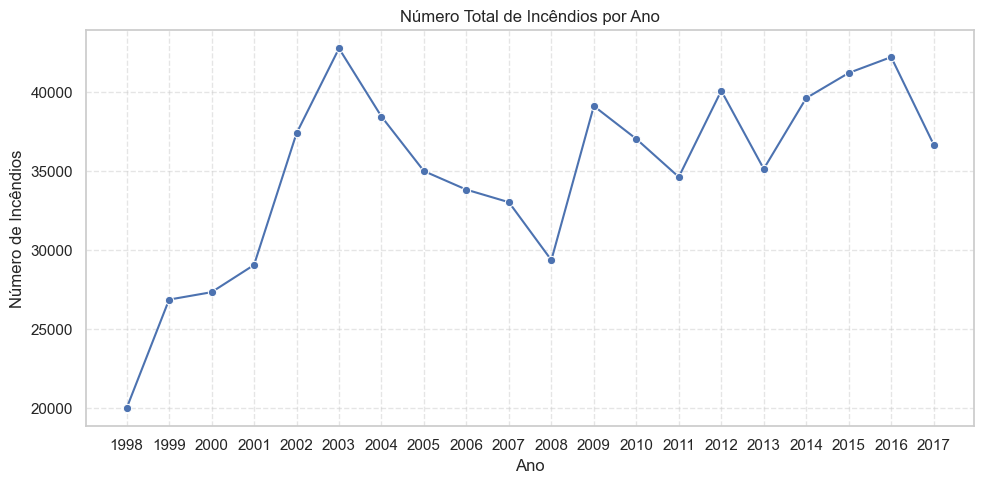

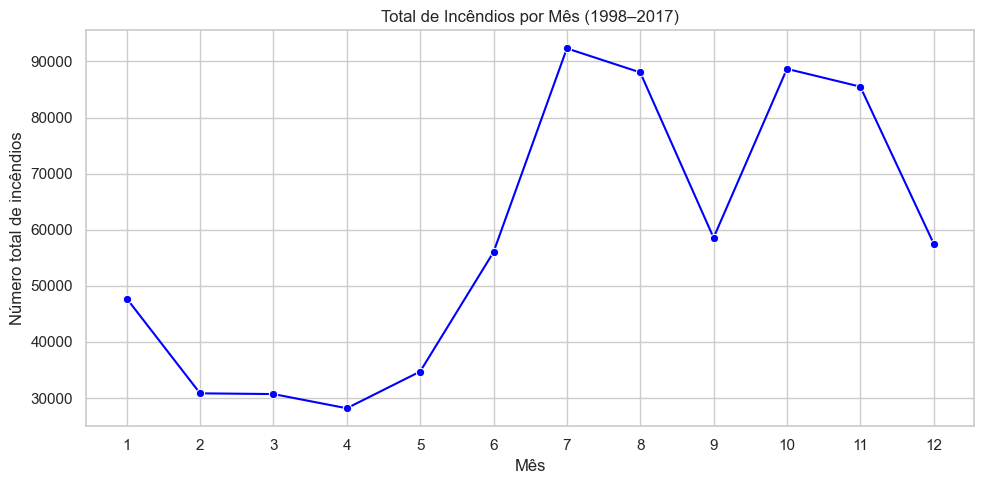

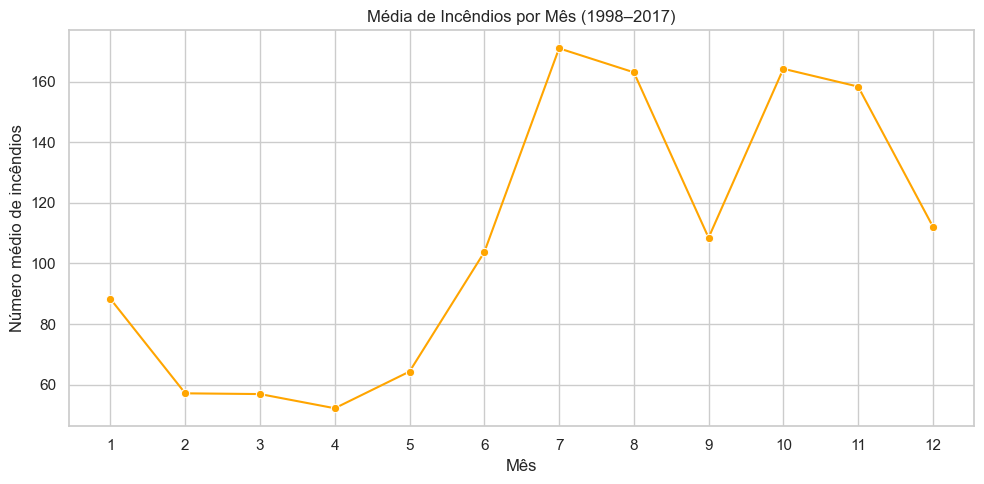

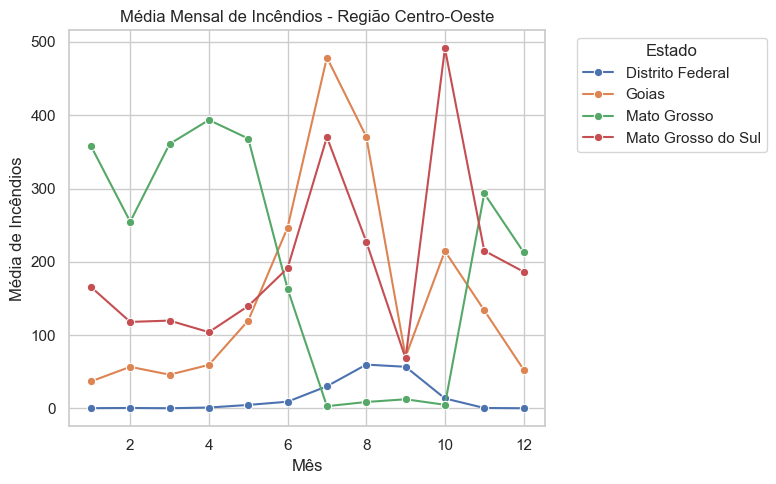

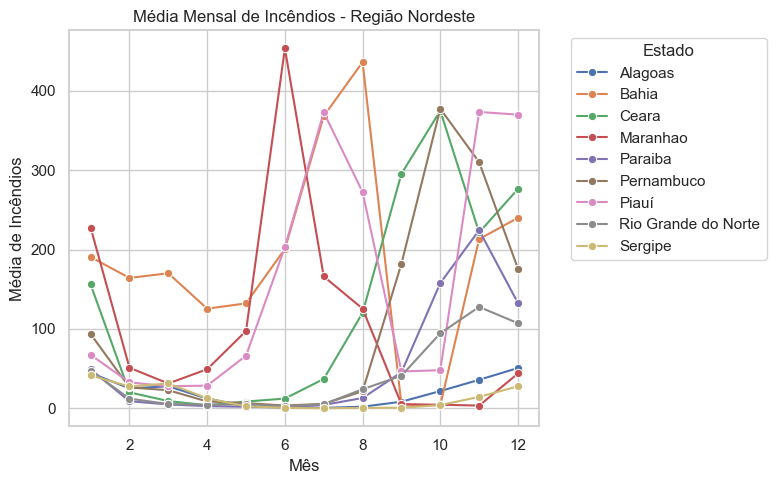

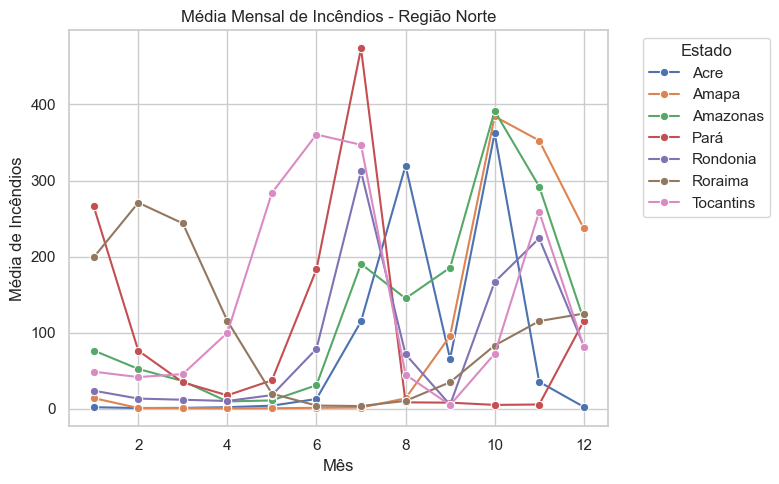

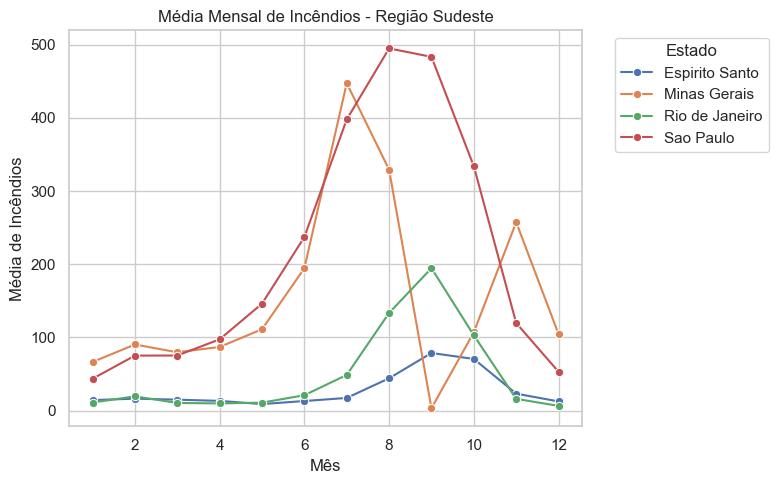

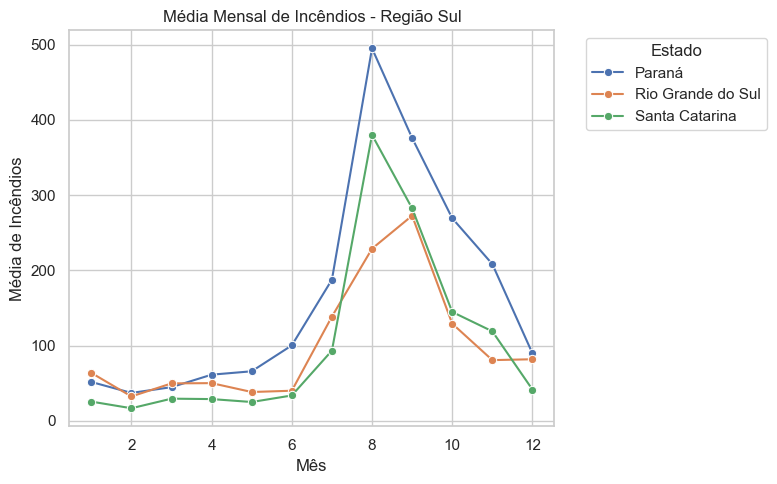

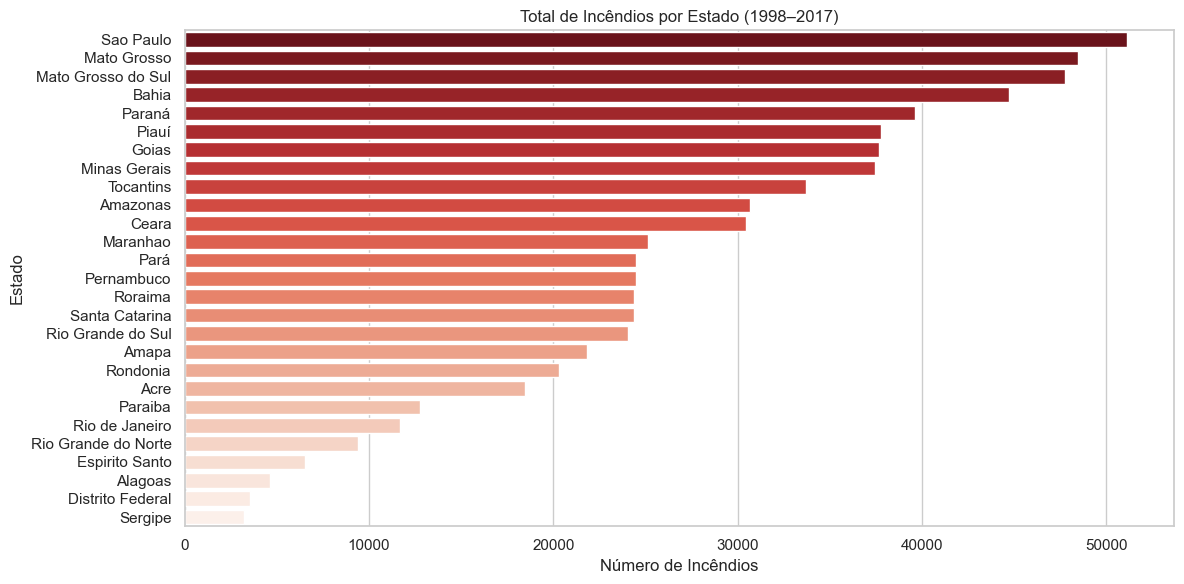

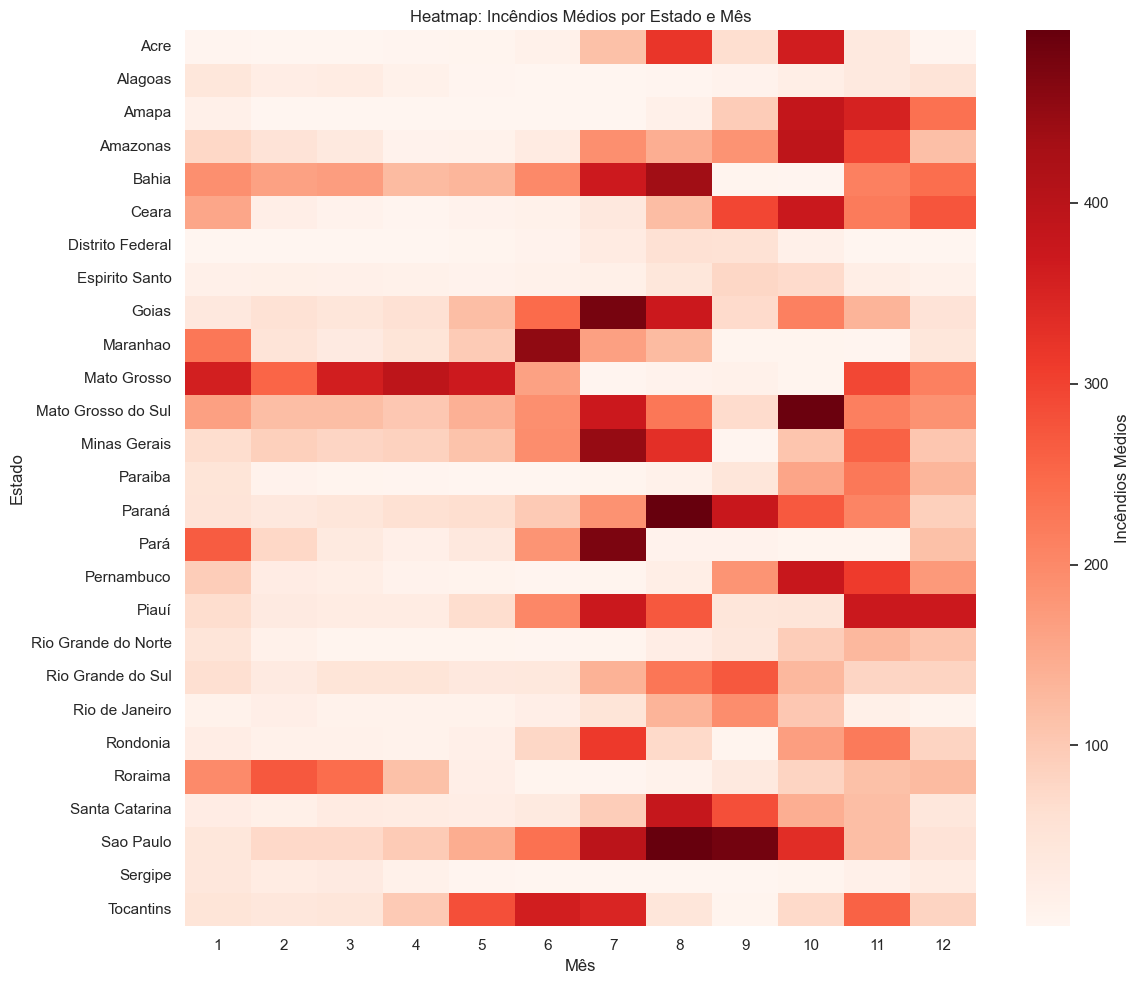

[OK] Análise exploratória concluída.


In [16]:
#main.py
def main():
    caminho_csv = "../data/amazonfire.csv"  # ajuste o caminho conforme sua estrutura
    df_processado = preprocessar_geral(caminho_csv)
    #print(df_processado.head())  # ou salvar em um novo CSV, se quiser
    print("Numero de NaN por coluna",df_processado.isnull().sum())


    # analise exploratoria
    eda(df_processado)

if __name__ == "__main__":
    main()
